# Aula 13 - Aprendizado Não Supervisionado - Parte 2 (Agrupamento Hierárquico & DBSCAN)

**Disciplina:** Aprendizado de Máquina e Redes Neurais  
**Professor:** Eduardo Lázaro Roesler de Oliveira  
**Instituição:** UNIVEM — Centro Universitário de Marília  

---

> [!NOTE]
> 🔙 **De onde viemos:** Na Aula 12, dominamos o K-Means e vimos sua eficiência em agrupamentos esféricos convexos. Porém, em cenários do mundo real com formatos não-lineares arbitrários e presença maciça de ruídos (*outliers*), precisamos de algoritmos mais flexíveis e resistentes à geometria dos dados.
> 🎯 **Objetivo Principal da Aula:** Dominar o **Agrupamento Hierárquico Aglomerativo** (com geração e leitura de **Dendrogramas**) e o algoritmo baseado em densidade **DBSCAN**, compreendendo os parâmetros de raio (`eps`) e densidade mínima (`min_samples`), e identificando anomalias rotuladas como ruído.
> 🚀 **Para onde vamos:** Na próxima aula ('Aprendizado Não Supervisionado - Parte 3'), resolveremos o pesadelo de todo cientista de dados: como analisar, agrupar e visualizar tabelas gigantes com 30, 50 ou 100 colunas usando **Redução de Dimensionalidade (PCA)**?

---

## Organização Tática da Aula

| Módulo | Atividade | Foco Pedagógico |
| :--- | :--- | :--- |
| **Módulo 1** | **Fundamentação Teórica & Limitações do K-Means** | Por que o K-Means falha em formatos geométricos não-esféricos (anéis, luas) e o conceito de densidade. |
| **Módulo 2** | **Agrupamento Hierárquico vs. DBSCAN** | Construção da árvore de conexões (Dendrograma), o parâmetro `eps` (raio de vizinhança) e `min_samples`. |
| **Módulo 3** | **Prática Guiada no Google Colab** | 6 blocos de código em Python minuciosamente comentados linha por linha com caixas de dúvidas. |
| **Módulo 4** | **Prática Orientada & Experimentação Fácil** | Detecção de anomalias em logs de tráfego com ajuste dos parâmetros `eps` e `min_samples` no DBSCAN. |
| **Módulo 5** | **Checklist de Autonomia & Bibliografia** | Autoavaliação do estudante e referências oficiais. |

---

## Módulo 1: Fundamentação Teórica & Agrupamentos Não-Lineares

### 1.1 As Limitações do K-Means
O K-Means assume que os clusters são **esféricos (circulares)** e de tamanho similar. No entanto, no mundo real, dados podem formar estruturas complexas como **anéis concêntricos**, **formatos em meia-lua** ou possuir **pontos de ruído isolados**.

```mermaid
graph TD
    A["🔵 PONTOS DENSOS NO ESPAÇO"] --> B{"DBSCAN (Análise por Densidade)"}
    B -->|Vizinhos >= min_samples| C["🟢 PONTO DE NÚCLEO / CLUSTER"]
    B -->|Sem vizinhos no raio eps| D["🚨 RÓTULO -1 (RUÍDO / OUTLIER)"]
```

> [!TIP]
> 🚀 **Analogia Geek — Detectando Impostores em Among Us com DBSCAN:**
> O K-Means falha em detectar o impostor porque ele força todo mundo a pertencer a algum grupo. O **DBSCAN** analisa a **densidade de pessoas juntas** em cada sala da nave. Qualquer tripulante vagando sozinho em uma sala escura distante de todos é automaticamente isolado e marcado com **Rótulo -1 (Ruído / Impostor)**!

> [!NOTE]
> 💡 **Curiosidade da Aula — O Prêmio "Test of Time" do DBSCAN:**
> O algoritmo DBSCAN foi apresentado em **1996 por Martin Ester, Hans-Peter Kriegel, Jörg Sander e Xiaowei Xu**. Em 2014, ele recebeu o prestigiado prêmio *Test of Time Award* na conferência SIGKDD por continuar sendo um dos algoritmos de detecção de anomalias e espacial mais eficientes já criados pela humanidade!  
> 🔗 **Documentação Scikit-Learn:** [scikit-learn DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html)

> [!IMPORTANT]
> 💡 **Em 1 Frase:** Enquanto o K-Means força todos os pontos a pertencerem a círculos rígidos, o DBSCAN descobre grupos de qualquer formato geométrico por densidade e isola outliers com o rótulo -1.

---

## Módulo 2: O Mecanismo por Dentro & Regras Práticas

### 2.1 Agrupamento Hierárquico Aglomerativo
Inicia considerando cada ponto como seu próprio cluster e vai fundindo iterativamente os pares de clusters mais próximos (visualizado via **Dendrograma**).

### 2.2 DBSCAN (Density-Based Spatial Clustering)
Agrupa pontos que estão densamente conectados com base em dois hiperparâmetros:
1. `eps` ($\epsilon$): A distância raio máxima entre dois pontos vizinhos.
2. `min_samples`: O número mínimo de pontos vizinhos para formar uma região densa.

> [!IMPORTANT]
> 💡 **Em 1 Frase:** O Agrupamento Hierárquico cria uma árvore visual de fusão de dados (Dendrograma), enquanto o DBSCAN exige apenas a definição do raio de vizinhança (`eps`) e quantidade mínima de vizinhos (`min_samples`).

---

## Módulo 3: Prática Guiada no Google Colab

Abra o [Google Colab](https://colab.research.google.com), crie um novo Notebook e acompanhe os blocos de código abaixo.

> [!NOTE]
> **Roteiro de estudo:** compare os dois métodos pela pergunta que respondem. DBSCAN encontra regiões densas e pode marcar ruídos; o agrupamento hierárquico mostra relações entre grupos em um dendrograma. `eps`, `min_samples` e a matriz de conexões são primeiros contatos: altere um valor por vez e observe o efeito.

---

### Bloco 3.1 — Importação das Bibliotecas e Gerando Dataset Meia-Lua

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Por que usamos o dataset `make_moons`?**  
> Porque as duas meias-luas entrelaçadas são o exemplo perfeito de formato não-circular onde o K-Means falharia miseravelmente, mas o DBSCAN acerta com perfeição!

In [1]:
# 1. Importamos as bibliotecas de processamento, gráficos e agrupamento
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons
from scipy.cluster.hierarchy import dendrogram, linkage

# 2. Geramos 300 pontos sintéticos em formato de duas meias-luas interligadas
matriz_pontos_meia_lua, _ = make_moons(n_samples=300, noise=0.08, random_state=42)

# 3. Exibimos a dimensão do dataset gerado
print("--- DATASET MEIA-LUA GERADO ---")
print(f"📐 Dimensão da Matriz X: {matriz_pontos_meia_lua.shape} (300 amostras, 2 atributos)")

--- DATASET MEIA-LUA GERADO ---
📐 Dimensão da Matriz X: (300, 2) (300 amostras, 2 atributos)


---

### Bloco 3.2 — Padronização de Escala (`StandardScaler`)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Por que a padronização de escala é obrigatória antes de rodar o DBSCAN?**  
> Como o DBSCAN mede o raio de vizinhança `eps` em unidades de distância geométrica, todas as colunas precisam estar rigorosamente na mesma escala (`StandardScaler`).

In [2]:
# 1. Instanciamos e aplicamos o escalonador padronizado
escalonador_padronizado = StandardScaler()
matriz_pontos_padronizada = escalonador_padronizado.fit_transform(matriz_pontos_meia_lua)

# 2. Exibimos mensagem de confirmação no console
print("--- PADRONIZAÇÃO DE ESCALA ---")
print("✅ Dados padronizados com Média = 0 e Desvio Padrão = 1.")

--- PADRONIZAÇÃO DE ESCALA ---
✅ Dados padronizados com Média = 0 e Desvio Padrão = 1.


---

### Bloco 3.3 — Instanciando e Executando o DBSCAN (`eps=0.25`, `min_samples=5`)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que indicam os parâmetros `eps=0.25` e `min_samples=5`?**  
> `eps=0.25` é o raio da vizinhança e `min_samples=5` diz que para ser considerado um centro denso, um ponto precisa ter pelo menos 5 vizinhos dentro desse raio de $0.25$.

In [3]:
# 1. Instanciamos o DBSCAN com raio eps=0.25 e mínimo de 5 amostras por núcleo
modelo_dbscan = DBSCAN(eps=0.25, min_samples=5)

# 2. O MOMENTO DO AGRUPAMENTO POR DENSIDADE: O modelo identifica clusters e ruídos
rotulos_dbscan_densidade = modelo_dbscan.fit_predict(matriz_pontos_padronizada)

# 3. Exibimos os rótulos únicos identificados (ex: 0, 1 e -1 para ruídos)
print("--- CLUSTERS ENCONTRADOS PELO DBSCAN ---")
print("Rótulos únicos de clusters encontrados pelo DBSCAN:", set(rotulos_dbscan_densidade))

--- CLUSTERS ENCONTRADOS PELO DBSCAN ---
Rótulos únicos de clusters encontrados pelo DBSCAN: {np.int64(0), np.int64(1), np.int64(-1)}


---

### Bloco 3.4 — Visualizando o Agrupamento DBSCAN nas Meias-Luas

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que significa o rótulo `-1` no DBSCAN?**  
> Pontos rotulados com `-1` são classificados como **Ruídos ou Outliers**! Significa que eles estavam isolados no espaço e não tinham vizinhos suficientes para formar um grupo denso.

🎨 Exibindo o agrupamento por densidade do DBSCAN no Colab...


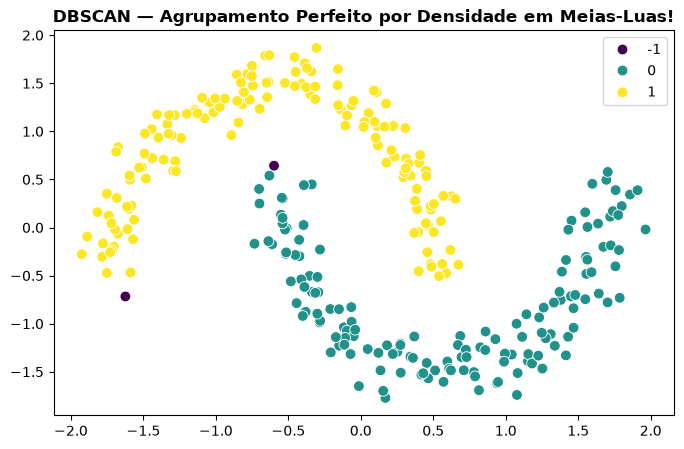

🚨 Total de Pontos Isolados de Ruído (Rótulo -1): 2


In [4]:
# 1. Definimos o tamanho da figura do gráfico
plt.figure(figsize=(8, 5))

# 2. Desenhamos a dispersão colorindo cada ponto com base no rótulo retornado pelo DBSCAN
sns.scatterplot(
    x=matriz_pontos_padronizada[:, 0], 
    y=matriz_pontos_padronizada[:, 1], 
    hue=rotulos_dbscan_densidade, 
    palette='viridis', 
    s=60
)

# 3. Adicionamos o título ao gráfico
plt.title("DBSCAN — Agrupamento Perfeito por Densidade em Meias-Luas!", fontweight='bold')

# 4. Renderizamos o gráfico e exibimos a contagem de pontos isolados
print("🎨 Exibindo o agrupamento por densidade do DBSCAN no Colab...")
plt.show()

print(f"🚨 Total de Pontos Isolados de Ruído (Rótulo -1): {list(rotulos_dbscan_densidade).count(-1)}")

---

### Bloco 3.5 — Treinando o Agrupamento Hierárquico Aglomerativo

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que é o parâmetro `linkage='ward'`?**  
> É o critério de fusão entre clusters que minimiza a variância total dentro de cada grupo ao unir dois clusters vizinhos.

In [5]:
# 1. Instanciamos o Agrupamento Hierárquico Aglomerativo para 2 clusters usando o método Ward
modelo_hierarquico = AgglomerativeClustering(n_clusters=2, linkage='ward')

# 2. Executamos o agrupamento nas amostras padronizadas
rotulos_agrupamento_hierarquico = modelo_hierarquico.fit_predict(matriz_pontos_padronizada)

# 3. Exibimos a confirmação de execução
print("--- AGRUPAMENTO HIERÁRQUICO AGLOMERATIVO TREINADO ---")
print("✅ Agrupamento Hierárquico Aglomerativo concluído!")

--- AGRUPAMENTO HIERÁRQUICO AGLOMERATIVO TREINADO ---
✅ Agrupamento Hierárquico Aglomerativo concluído!


---

### Bloco 3.6 — Gerando a Matriz de Conexões e Plotando o Dendrograma

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Como ler um Dendrograma?**  
> É um gráfico em formato de árvore de cabeça para baixo. O eixo Y indica a distância em que dois grupos se fundiram. Quanto mais alta a linha horizontal, mais distantes eram os grupos antes de se unirem.

🎨 Exibindo a árvore de conexões (Dendrograma) no Colab...


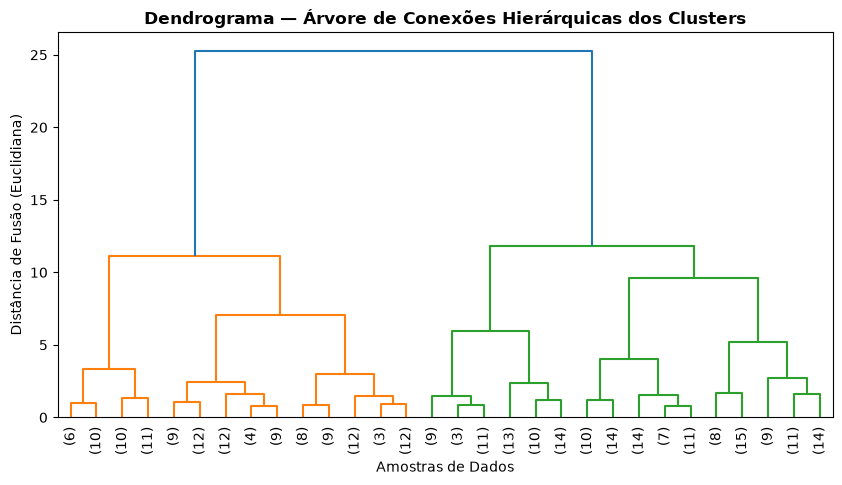

In [6]:
# 1. Calculamos a matriz de ligações hierárquicas usando a função linkage do SciPy
matriz_ligacoes_hierarquicas = linkage(matriz_pontos_padronizada, method='ward')

# 2. Definimos as dimensões da figura do gráfico
plt.figure(figsize=(10, 5))

# 3. Desenhamos a árvore do Dendrograma truncando as últimas 30 fusões para melhor clareza visual
dendrogram(matriz_ligacoes_hierarquicas, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10)

# 4. Adicionamos rótulos aos eixos
plt.title("Dendrograma — Árvore de Conexões Hierárquicas dos Clusters", fontweight='bold')
plt.xlabel("Amostras de Dados")
plt.ylabel("Distância de Fusão (Euclidiana)")

# 5. Exibimos a imagem no notebook
print("🎨 Exibindo a árvore de conexões (Dendrograma) no Colab...")
plt.show()

---

## Módulo 4: Prática Orientada & Experimentação Fácil

### Roteiro de Personalização para o Estudante:
Altere os parâmetros do DBSCAN abaixo para ver a detecção de anomalias em um log de rede:

1. **Altere o raio `eps`:** Na linha `raio_eps_escolhido = 0.5`, mude para `0.3` ou `0.8`.
2. **Altere `min_samples`:** Na linha `minimo_amostras_escolhido = 4`, mude para `2` ou `8`.
3. **Re-execute e observe:** Veja quantos ataques/anomalias (Rótulo -1) foram identificados!

--- RELATÓRIO DO SEU TESTE (eps=0.5, min_samples=4) ---
🚨 ALERTAS DE ANOMALIA DETECTADOS (Rótulo -1): 4


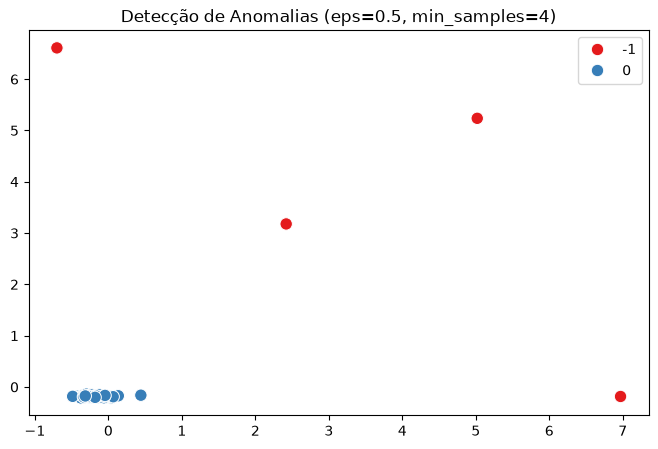

In [7]:
# =============================================================================
# CÓDIGO BASE PRONTO PARA SUA EXPERIMENTAÇÃO
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# 1. Geramos logs sintéticos de conexões de rede normais e 4 ataques/anomalias
np.random.seed(55)
conexao_normal = np.random.normal(loc=10, scale=2, size=(80, 2))
anomalias = np.array([[50, 500], [2, 1000], [120, 10], [90, 800]])

matriz_rede = np.vstack([conexao_normal, anomalias])
matriz_rede_padronizada = StandardScaler().fit_transform(matriz_rede)

# -----------------------------------------------------------------------------
# STEP 1: PASSO DE EXPERIMENTAÇÃO DO ALUNO — PERSONALIZE OS HIPERPARÂMETROS:
# -----------------------------------------------------------------------------
raio_eps_escolhido = 0.5            # Tente mudar para 0.3 ou 0.8
minimo_amostras_escolhido = 4       # Tente mudar para 2 ou 8

# 2. Executamos o DBSCAN personalizado do estudante
dbscan_personalizado = DBSCAN(eps=raio_eps_escolhido, min_samples=minimo_amostras_escolhido)
rotulos_rede_personalizados = dbscan_personalizado.fit_predict(matriz_rede_padronizada)

# 3. Contamos quantos alertas de anomalia (Rótulo -1) foram gerados
quantidade_anomalias_detectadas = np.sum(rotulos_rede_personalizados == -1)

# 4. Exibimos o relatório e o gráfico
print(f"--- RELATÓRIO DO SEU TESTE (eps={raio_eps_escolhido}, min_samples={minimo_amostras_escolhido}) ---")
print(f"🚨 ALERTAS DE ANOMALIA DETECTADOS (Rótulo -1): {quantidade_anomalias_detectadas}")

plt.figure(figsize=(8, 5))
sns.scatterplot(x=matriz_rede_padronizada[:, 0], y=matriz_rede_padronizada[:, 1], hue=rotulos_rede_personalizados, palette='Set1', s=80)
plt.title(f"Detecção de Anomalias (eps={raio_eps_escolhido}, min_samples={minimo_amostras_escolhido})")
plt.show()

---

### 🔮 Aquecimento & Spoiler da Próxima Aula (Para Ir Além)

> [!TIP]
> 🧠 **Conceito-Semente — O 'Mal da Dimensionalidade' e a Sombra 2D**  
> Nossos olhos e telas só conseguem enxergar em 2D ou 3D. Como fazer para analisar um dataset de saúde com 40 exames médicos por paciente? Na **Aula 14**, aprenderemos o **PCA (Principal Component Analysis)**: uma técnica brilhante de álgebra linear que 'projeta a sombra' de 40 dimensões em apenas 2 ou 3 eixos principais, mantendo mais de 90% da informação original intacta!
> 
> 🚀 **Desafio Proativo de Autoestudo (Opcional):**  
> Pense em uma escultura 3D de um cavalo e uma lanterna projetando sua sombra em uma parede 2D. Se você posicionar a lanterna no ângulo certo, ainda conseguirá reconhecer que a sombra é de um cavalo? Essa é a intuição visual do PCA!

---

## Módulo 5: Checklist de Autonomia do Estudante

- [ ] Compreendi por que o K-Means falha em agrupamentos não-circulares.
- [ ] Entendi como funciona o Agrupamento Hierárquico e os Dendrogramas.
- [ ] Sei implementar o DBSCAN e ajustar os hiperparâmetros `eps` e `min_samples`.
- [ ] Entendi que o rótulo `-1` no DBSCAN identifica pontos de ruído e anomalias.
- [ ] Consigo alterar os valores do raio `eps` e observar a variação de anomalias detectadas.

---

## Referências Bibliográficas & Documentações Oficiais

- 📖 **Livro Texto:** Géron, A. — *Mãos à Obra: Aprendizado de Máquina com Scikit-Learn, Keras & TensorFlow* (Capítulo 9: DBSCAN).
- 🔗 **Documentação Scikit-Learn:** [scikit-learn DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html)

---

# 🧪 Extensão Prática Avançada: Laboratório Técnico com Dados Reais (`pratica_real.md`)

> 🔬 **Sobre esta Extensão:**  
> Esta seção adicional consolida o aprendizado com uma abordagem **mais avançada, direta e profissional**, sem dados sintéticos e utilizando datasets reais consagrados da Ciência de Dados.


# Laboratório Prático — Aula 13: DBSCAN & Agrupamento Hierárquico

**Disciplina:** Aprendizado de Máquina e Redes Neurais  
**Professor:** Eduardo Lázaro Roesler de Oliveira  
**Instituição:** UNIVEM — Centro Universitário de Marília  
**Dataset Real/Sintético:** *Two Moons Dataset* com ruído & *Iris Dataset* (Dendrogramas)

---

## 🎯 Objetivo do Laboratório
Demonstrar na prática a falha do K-Means em dados de geometria não-convexa e o sucesso do **DBSCAN** baseado em densidade (`eps` e `min_samples`), identificar ruídos/outliers marcados com `-1` e gerar o **Dendrograma Hierárquico Aglomerativo**.

---

### Passo 1 — Gerando Dados em Meia-Lua com Ruído

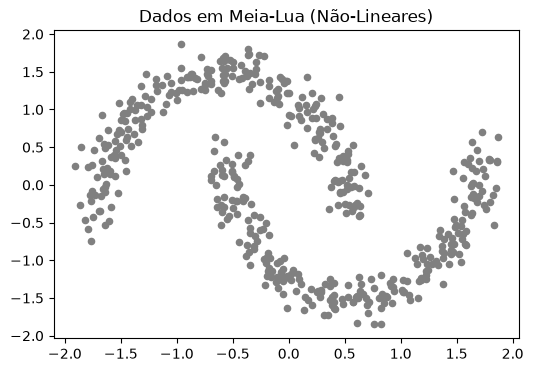

In [8]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Geramos 500 pontos em formato entrelaçado de meias-luas
X_moons, _ = make_moons(n_samples=500, noise=0.08, random_state=42)
X_moons = StandardScaler().fit_transform(X_moons)

plt.figure(figsize=(6, 4))
plt.scatter(X_moons[:, 0], X_moons[:, 1], s=20, color='gray')
plt.title("Dados em Meia-Lua (Não-Lineares)")
plt.show()

---

### Passo 2 — K-Means (Falha) vs DBSCAN (Sucesso)

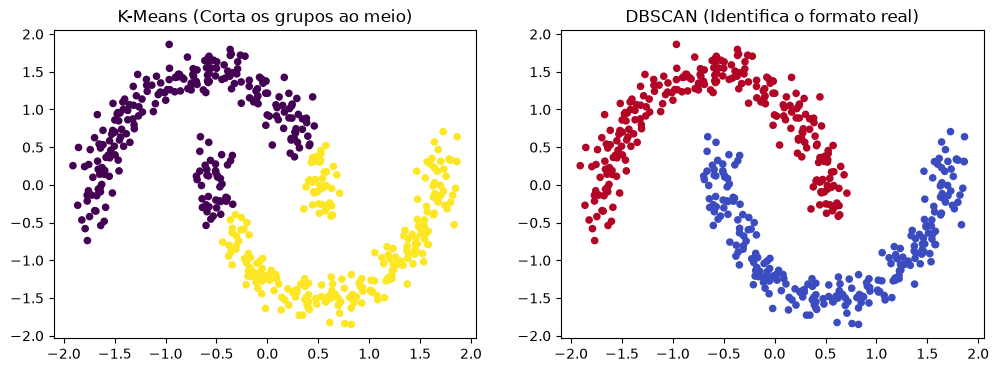

Total de ruídos / outliers identificados pelo DBSCAN: 0


In [9]:
from sklearn.cluster import KMeans, DBSCAN

# 1. K-Means (Assume clusters circulares)
labels_km = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_moons)

# 2. DBSCAN (Agrupa por continuidade de densidade)
labels_db = DBSCAN(eps=0.25, min_samples=5).fit_predict(X_moons)

# 3. Plotamos a comparação lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_km, cmap='viridis', s=20)
ax1.set_title("K-Means (Corta os grupos ao meio)")

ax2.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_db, cmap='coolwarm', s=20)
ax2.set_title("DBSCAN (Identifica o formato real)")
plt.show()

print(f"Total de ruídos / outliers identificados pelo DBSCAN: {sum(labels_db == -1)}")

---

### Passo 3 — Gerando o Dendrograma no Dataset Iris

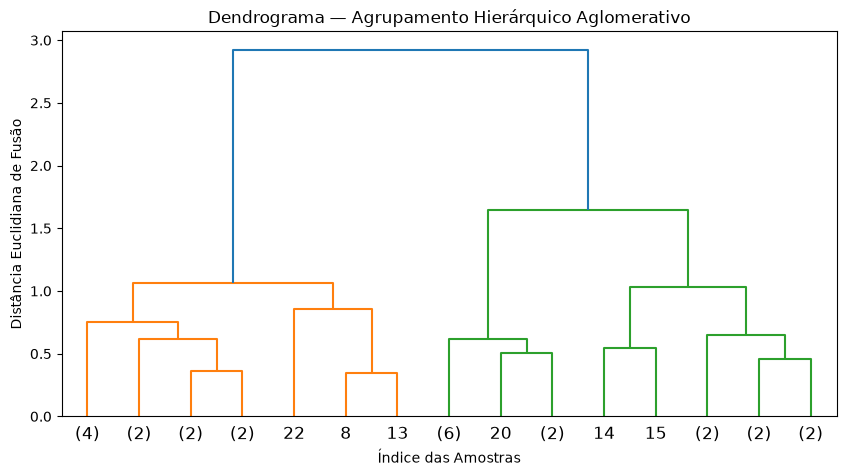

In [10]:
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Carregamos uma amostra de 30 flores do Iris
X_iris, _ = load_iris(return_X_y=True)
X_amostra = X_iris[:30]

# 2. Calculamos a matriz de conexões (Linkage com método Ward)
matriz_conexoes = linkage(X_amostra, method='ward')

# 3. Plotamos o Dendrograma
plt.figure(figsize=(10, 5))
dendrogram(matriz_conexoes, truncate_mode='lastp', p=15, show_leaf_counts=True)
plt.title("Dendrograma — Agrupamento Hierárquico Aglomerativo")
plt.xlabel("Índice das Amostras")
plt.ylabel("Distância Euclidiana de Fusão")
plt.show()

---

## 🏆 Desafio Técnico de Validação
Altere o parâmetro `eps` do DBSCAN para `0.10` e observe como o número de pontos considerados ruído (`label == -1`) aumenta drasticamente por causa do raio muito restrito.

In [11]:
# =============================================================================
# ESPAÇO PARA RESOLUÇÃO DO DESAFIO TÉCNICO
# Implemente seu código abaixo para validar o desafio proposto:
# =============================================================================
